Análisis de la Industria de Videojuegos (1980 - 2020)

In [1]:
#instala pandas
pip install pandas

SyntaxError: invalid syntax (1134559820.py, line 2)

In [3]:
#Importo librerias

import pandas as pd 

import numpy as np

# Carga el dataset

df = pd.read_csv("/workspaces/proyecto-final-videojuegos-/data/vgsales.csv")



In [4]:
# analiza registros y columnas reales
df.shape

(16598, 11)

In [5]:
#contemplo el df
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [6]:
#Reviso los tipos de datos 
df.dtypes

Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [7]:
# chequeamos los nulos

df.isnull()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
16593,False,False,False,False,False,False,False,False,False,False,False
16594,False,False,False,False,False,False,False,False,False,False,False
16595,False,False,False,False,False,False,False,False,False,False,False
16596,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [11]:
# Creo Copia de seguridad

df_limpio = df.copy()

In [14]:
# tome la desicion de eliminal las filas donde el año es nulo 
#ya que son (271 nulos - 1.6% de los datos) Como representan apenas 
# el 1.6% de todo el volumen de datos, perderlas no va a 
#  distorsionar nuestras conclusiones estadísticas sobre el mercado global

df_limpio = df.dropna(subset=["Year"]).copy()

#relleno los nulos 

df_limpio["Publisher"] = df_limpio["Publisher"].fillna("Sin datos")

# conversion de años a tipo int

df_limpio["Year"] = df_limpio["Year"].astype(int)


In [17]:
#verificacion

df_limpio.isnull().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [19]:
print(f"\nFilas originales: {len(df)} | Filas después de la limpieza: {len(df_limpio)}")
print(f"Porcentaje de datos conservados: {len(df_limpio) / len(df) * 100:.2f}%")


Filas originales: 16598 | Filas después de la limpieza: 16327
Porcentaje de datos conservados: 98.37%


In [28]:
pip install matplotlib



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


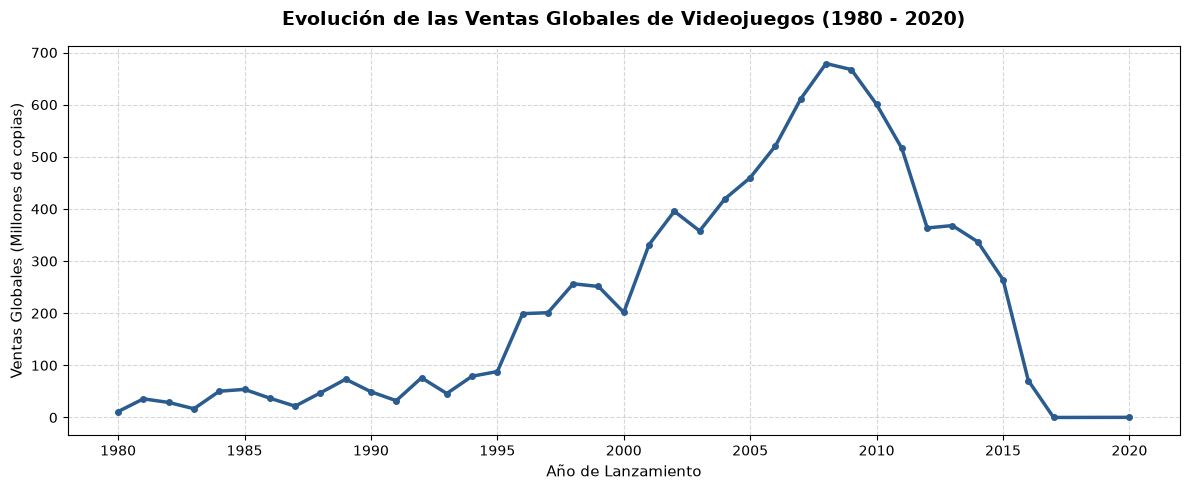

In [31]:
#Analicis evaulacion de ventas por año
import matplotlib.pyplot as plt
import seaborn as sns

#agrupo por año
ventas_por_anio = df_limpio.groupby("Year")["Global_Sales"].sum().reset_index()

#grafico de tendencia temporal

plt.figure(figsize=(12, 5))
plt.plot(ventas_por_anio["Year"], ventas_por_anio["Global_Sales"], color="#2b5c8f", linewidth=2.5, marker="o", markersize=4)

plt.title("Evolución de las Ventas Globales de Videojuegos (1980 - 2020)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Año de Lanzamiento", fontsize=11)
plt.ylabel("Ventas Globales (Millones de copias)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()